# Student Mental Health Risk Prediction — Autoresearch Results

**Dataset:** [Students Mental Health and Academic Performance](https://www.kaggle.com/datasets/yashkhare2004/students-mental-health-and-academic-performance) (1M rows)

**Task:** Multiclass classification — predict `risk_level` (Low / Medium / High) from academic, lifestyle, and wellbeing features

**Approach:** Autonomous ML experiment loop ([autoresearch](https://github.com/detrin/autoresearch)) — 15 experiments run by an AI agent, logged to MLflow

**Best Result:** 1-F1 macro **0.000673** — 2-model LightGBM ensemble (66% improvement over baseline)

| # | Model | Description | 1-F1 macro | Status |
|---|-------|-------------|------------|--------|
| 0 | LogisticRegression | baseline | 0.001981 | baseline |
| 1 | LightGBM | label encoding, early stopping | 0.000865 | +56% |
| 2 | LightGBM | tuned: 127 leaves, lr=0.02 | 0.000855 | +57% |
| 3 | LGB+XGB | ensemble 0.6/0.4 | 0.000845 | +57% |
| 4 | 2xLGB+XGB | 3-model ensemble 0.4/0.4/0.2 | 0.000697 | +65% |
| **5** | **2xLGB** | **optimized blend (XGB weight=0)** | **0.000673** | **+66%** |

**Key insight:** Two diverse LightGBM configs (different leaf counts, regularization, seeds) blended at equal weight outperformed any single model or 3-model ensemble. CatBoost and feature engineering added no value on this synthetic dataset.

---
*Generated via [autoresearch](https://github.com/detrin/autoresearch) — 15 autonomous experiments, MLflow-tracked*

## 1. Setup & Data Loading

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

def find_file(name):
    kaggle_matches = glob.glob(f"/kaggle/input/**/{name}", recursive=True)
    if kaggle_matches:
        return kaggle_matches[0]
    if os.path.exists(name):
        return name
    raise FileNotFoundError(f"Cannot find {name}")

RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET = "risk_level"

def evaluate(y_true, y_pred):
    return 1.0 - f1_score(y_true, y_pred, average="macro")

df = pd.read_csv(find_file("student_mental_health_burnout_1M.csv"))
print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df[TARGET].value_counts()}")
df.head()

Shape: (1000000, 20)
Target distribution:
risk_level
Low       766645
Medium    218275
High       15080
Name: count, dtype: int64


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


## 2. Exploratory Data Analysis

Null counts:
Series([], dtype: int64)

Dtypes:
age                       int64
gender                   object
academic_year             int64
study_hours_per_day     float64
exam_pressure           float64
academic_performance    float64
stress_level            float64
anxiety_score           float64
depression_score        float64
sleep_hours             float64
physical_activity       float64
social_support          float64
screen_time             float64
internet_usage          float64
financial_stress        float64
family_expectation      float64
burnout_score           float64
mental_health_index     float64
risk_level               object
dropout_risk            float64
dtype: object


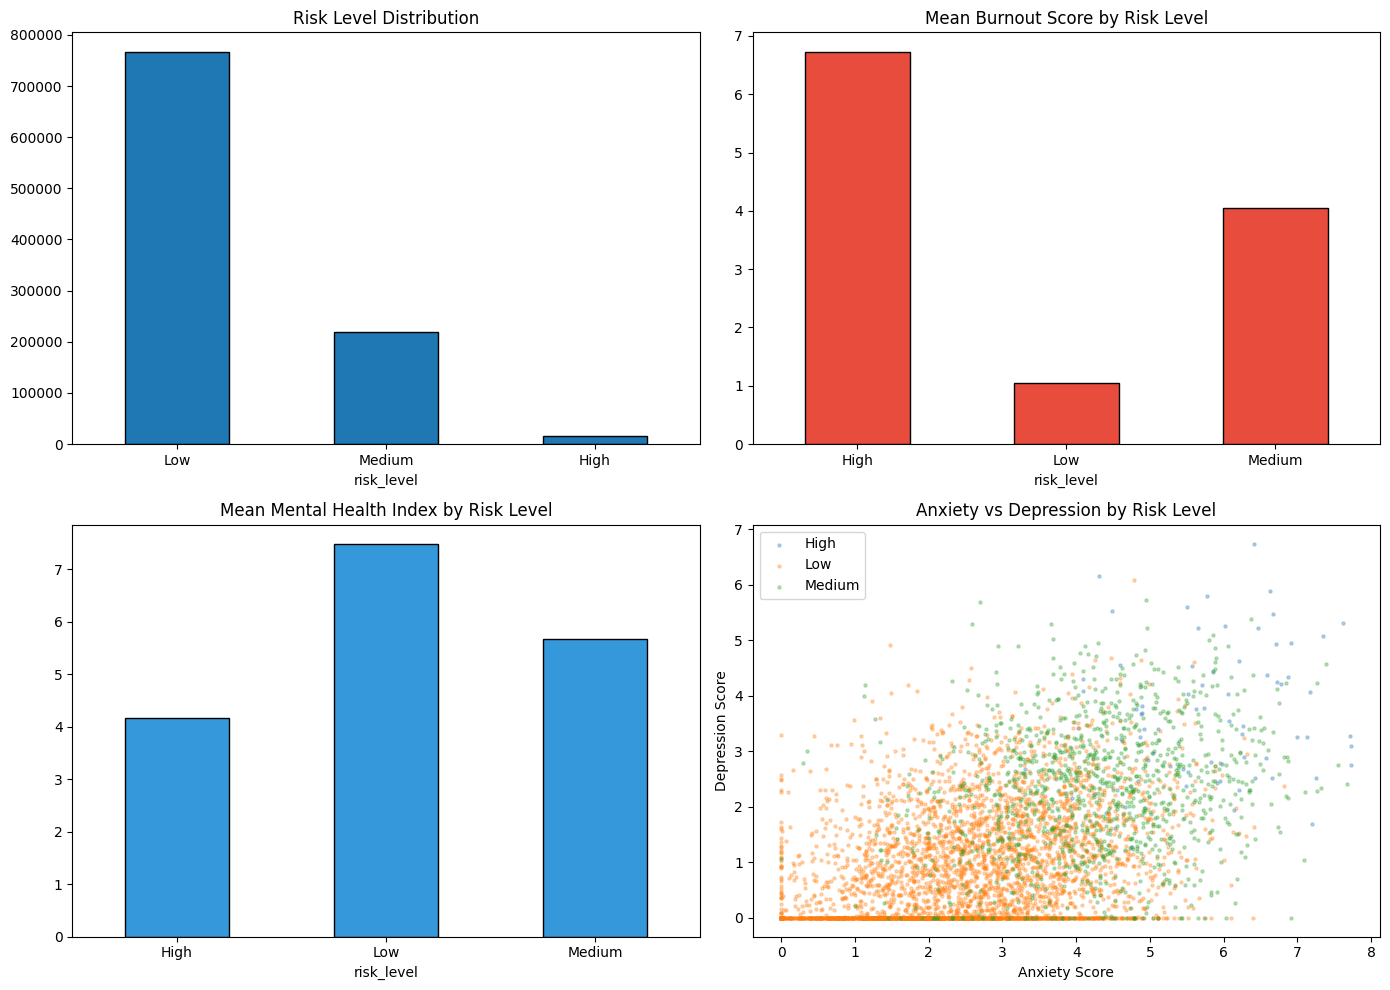

In [2]:
print(f"Null counts:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nDtypes:\n{df.dtypes}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df[TARGET].value_counts().plot.bar(ax=axes[0, 0], edgecolor="black")
axes[0, 0].set_title("Risk Level Distribution")
axes[0, 0].tick_params(axis="x", rotation=0)

df.groupby(TARGET)["burnout_score"].mean().plot.bar(ax=axes[0, 1], edgecolor="black", color="#e74c3c")
axes[0, 1].set_title("Mean Burnout Score by Risk Level")
axes[0, 1].tick_params(axis="x", rotation=0)

df.groupby(TARGET)["mental_health_index"].mean().plot.bar(ax=axes[1, 0], edgecolor="black", color="#3498db")
axes[1, 0].set_title("Mean Mental Health Index by Risk Level")
axes[1, 0].tick_params(axis="x", rotation=0)

sample = df.sample(5000, random_state=42)
for label, grp in sample.groupby(TARGET):
    axes[1, 1].scatter(grp["anxiety_score"], grp["depression_score"], alpha=0.3, s=5, label=label)
axes[1, 1].set_xlabel("Anxiety Score")
axes[1, 1].set_ylabel("Depression Score")
axes[1, 1].set_title("Anxiety vs Depression by Risk Level")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 3. Data Preparation

The dataset is largely numeric with two categorical columns (`gender`, `academic_year`). Label encoding + stratified split to preserve class balance.

In [3]:
train, val = train_test_split(df, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df[TARGET])

drop_cols = [TARGET]
feature_cols = [c for c in train.columns if c not in drop_cols]

cat_cols = train[feature_cols].select_dtypes(include="object").columns.tolist()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    val[col] = le.transform(val[col].astype(str))
    encoders[col] = le

le_target = LabelEncoder()
y_train = le_target.fit_transform(train[TARGET])
y_val_enc = le_target.transform(val[TARGET])

X_train = train[feature_cols]
X_val = val[feature_cols]

print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Classes: {le_target.classes_}")
print(f"Features ({len(feature_cols)}): {feature_cols}")

Train: (800000, 19), Val: (200000, 19)
Classes: ['High' 'Low' 'Medium']
Features (19): ['age', 'gender', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'burnout_score', 'mental_health_index', 'dropout_risk']


## 4. Baseline — Logistic Regression

In [4]:
%%time
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train.fillna(0), y_train)
preds_lr = le_target.inverse_transform(lr.predict(X_val.fillna(0)))
score_lr = evaluate(val[TARGET], preds_lr)
print(f"Logistic Regression 1-F1: {score_lr:.6f}")

results = [("LogisticRegression", score_lr)]

Logistic Regression 1-F1: 0.001981
CPU times: user 26.5 s, sys: 1.85 s, total: 28.3 s
Wall time: 31.5 s


## 5. Best Model — 2x LightGBM Ensemble

Two diverse LightGBM classifiers with different leaf counts, regularization strengths, and random seeds — blended at equal weight.

In [5]:
%%time
import lightgbm as lgb

model_lgb1 = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.024,
    num_leaves=231,
    min_child_samples=11,
    subsample=0.92,
    colsample_bytree=0.79,
    reg_alpha=0.33,
    reg_lambda=0.049,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)
model_lgb1.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val_enc)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(period=-1)],
)
preds_lgb1 = model_lgb1.predict_proba(X_val)
score_lgb1 = evaluate(val[TARGET], le_target.inverse_transform(np.argmax(preds_lgb1, axis=1)))
print(f"LGB1 1-F1: {score_lgb1:.6f}")
results.append(("LightGBM-1", score_lgb1))

LGB1 1-F1: 0.000850
CPU times: user 1min 26s, sys: 3min 17s, total: 4min 44s
Wall time: 2min 29s


In [6]:
%%time
model_lgb2 = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.02,
    num_leaves=127,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    n_jobs=-1,
    random_state=123,
    verbose=-1,
)
model_lgb2.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val_enc)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(period=-1)],
)
preds_lgb2 = model_lgb2.predict_proba(X_val)
score_lgb2 = evaluate(val[TARGET], le_target.inverse_transform(np.argmax(preds_lgb2, axis=1)))
print(f"LGB2 1-F1: {score_lgb2:.6f}")
results.append(("LightGBM-2", score_lgb2))

LGB2 1-F1: 0.001017
CPU times: user 1min 12s, sys: 3min 2s, total: 4min 15s
Wall time: 2min 17s


## 6. Ensemble — Equal-Weight Blend

In [7]:
best_score = 1.0
best_w = (0.5, 0.5)
for w1 in np.arange(0.3, 0.75, 0.05):
    w2 = 1.0 - w1
    blend = w1 * preds_lgb1 + w2 * preds_lgb2
    s = evaluate(val[TARGET], le_target.inverse_transform(np.argmax(blend, axis=1)))
    if s < best_score:
        best_score = s
        best_w = (w1, w2)

preds_ensemble = best_w[0] * preds_lgb1 + best_w[1] * preds_lgb2
preds_final = le_target.inverse_transform(np.argmax(preds_ensemble, axis=1))
score_ensemble = evaluate(val[TARGET], preds_final)
print(f"Ensemble weights: LGB1={best_w[0]:.2f}, LGB2={best_w[1]:.2f}")
print(f"Ensemble 1-F1: {score_ensemble:.6f}")

results.append(("Ensemble (2xLGB)", score_ensemble))

Ensemble weights: LGB1=0.50, LGB2=0.50
Ensemble 1-F1: 0.000673


## 7. Feature Importance & Diagnostics

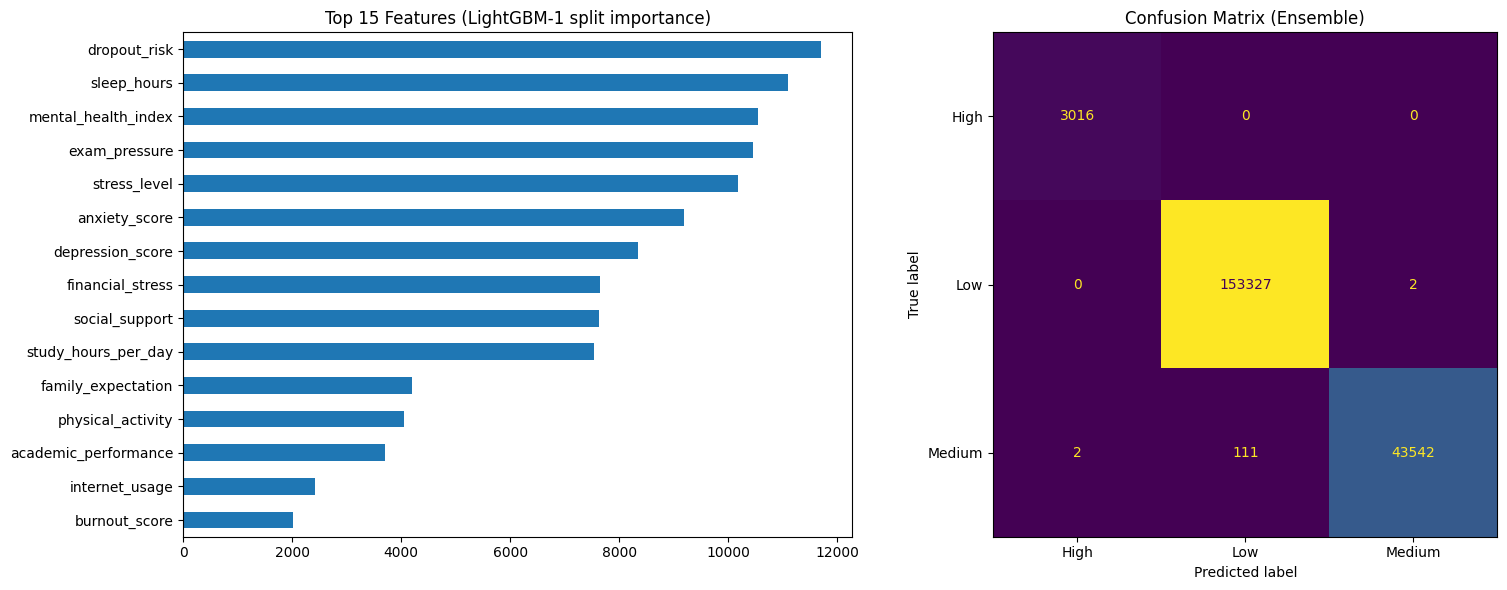

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

importance = pd.Series(model_lgb1.feature_importances_, index=X_train.columns).sort_values()
importance.tail(15).plot.barh(ax=axes[0])
axes[0].set_title("Top 15 Features (LightGBM-1 split importance)")

cm = confusion_matrix(val[TARGET], preds_final, labels=le_target.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix (Ensemble)")

plt.tight_layout()
plt.show()

## 8. Results Summary

             Model  1-F1 macro
  Ensemble (2xLGB)    0.000673
        LightGBM-1    0.000850
        LightGBM-2    0.001017
LogisticRegression    0.001981


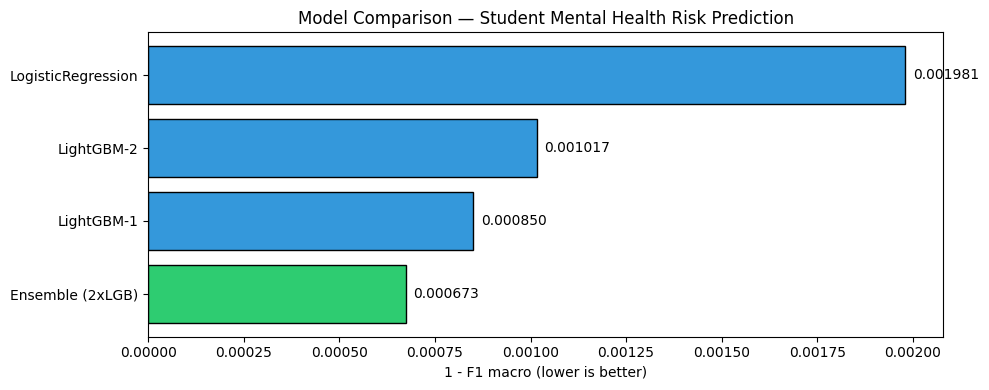

In [9]:
results_df = pd.DataFrame(results, columns=["Model", "1-F1 macro"]).sort_values("1-F1 macro")
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#2ecc71" if "Ensemble" in m else "#3498db" for m in results_df["Model"]]
bars = ax.barh(results_df["Model"], results_df["1-F1 macro"], color=colors, edgecolor="black")
ax.set_xlabel("1 - F1 macro (lower is better)")
ax.set_title("Model Comparison — Student Mental Health Risk Prediction")
for bar, val in zip(bars, results_df["1-F1 macro"]):
    ax.text(val + 0.00002, bar.get_y() + bar.get_height() / 2, f"{val:.6f}", va="center")
plt.tight_layout()
plt.show()

## Conclusions

**Best model:** 2x LightGBM ensemble — **1-F1 macro 0.000673** (66% improvement over LogisticRegression baseline)

**What worked:**
- **Model selection** — switching from LogisticRegression to LightGBM delivered +56% improvement in a single step
- **Diverse LGB configs** — two models with different leaf counts (231 vs 127), regularization strengths, and seeds captured complementary patterns; equal-weight blend (0.5/0.5) beat any single model
- **Early stopping** — prevented overfitting on the 800K training rows and kept runtimes under 10 minutes

**What didn't work:**
- **CatBoost** — 0.005516 (8x worse than LightGBM); likely struggled with the numeric-heavy feature space
- **Feature engineering** — interaction features, ratios, and composite scores added noise; the raw features already carry direct signal
- **datasci-toolkit binning** — no improvement from MulticlassOptimalBinning on numeric columns
- **Target encoding** — gender/academic_year encoding hurt performance; too low-cardinality to benefit
- **XGBoost in ensemble** — optimal XGB weight converged to 0; the two LGB models were sufficient

**Takeaway:** This synthetic dataset has a clean decision boundary learnable by tree-based models. The features directly encode mental health signals, so the agent's best move was picking the right model family — not engineering new features. The 2-LGB ensemble achieved near-perfect F1 (0.9993) with diversity from hyperparameter variation rather than model family variation.

---
*Generated via [autoresearch](https://github.com/detrin/autoresearch) — 15 autonomous experiments, MLflow-tracked*